# ObesityAI — Pipeline de Machine Learning
## FIAP POSTECH · Data Analytics · Tech Challenge Fase 4

**Objetivo:** Treinar um modelo preditivo de classificação de obesidade a partir de variáveis comportamentais e clínicas.


In [21]:
# Instalar dependências
!pip install scikit-learn matplotlib seaborn -q
!pip install scikit-learn==1.8.0 -q


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import pickle
import os
from io import BytesIO

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


## 1. Carregamento dos dados

In [24]:
from google.colab import files
uploaded = files.upload()   # <- selecione o arquivo Obesity.csv

DATA_PATH = "Obesity.csv"
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {df_raw.columns.tolist()}")
display(df_raw.head())


Saving Obesity.csv to Obesity (2).csv
Shape: (2111, 17)

Colunas: ['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Obesity']


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [25]:
# Distribuição do target
print("Distribuição do target (Obesity):")
display(df_raw["Obesity"].value_counts().to_frame())

# Verificar nulos
print(f"\nNulos por coluna:\n{df_raw.isnull().sum().to_string()}")


Distribuição do target (Obesity):


,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272



Nulos por coluna:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0


## 2. Análise Exploratória (EDA)

In [26]:
# Verificar se os dados têm características de SMOTE (valores decimais em Age)
pct_decimal_age    = (df_raw["Age"]    % 1 != 0).mean() * 100
pct_decimal_weight = (df_raw["Weight"] % 1 != 0).mean() * 100
print(f"Age com decimais:    {pct_decimal_age:.1f}% → indica amostras sintéticas (SMOTE)")
print(f"Weight com decimais: {pct_decimal_weight:.1f}% → confirma geração sintética")
print()
print("Referência: o dataset original UCI tem 498 registros reais.")
print(f"Dataset atual: {len(df_raw)} linhas → ~{len(df_raw)-498} geradas via SMOTE.")


Age com decimais:    65.1% → indica amostras sintéticas (SMOTE)
Weight com decimais: 68.8% → confirma geração sintética

Referência: o dataset original UCI tem 498 registros reais.
Dataset atual: 2111 linhas → ~1613 geradas via SMOTE.


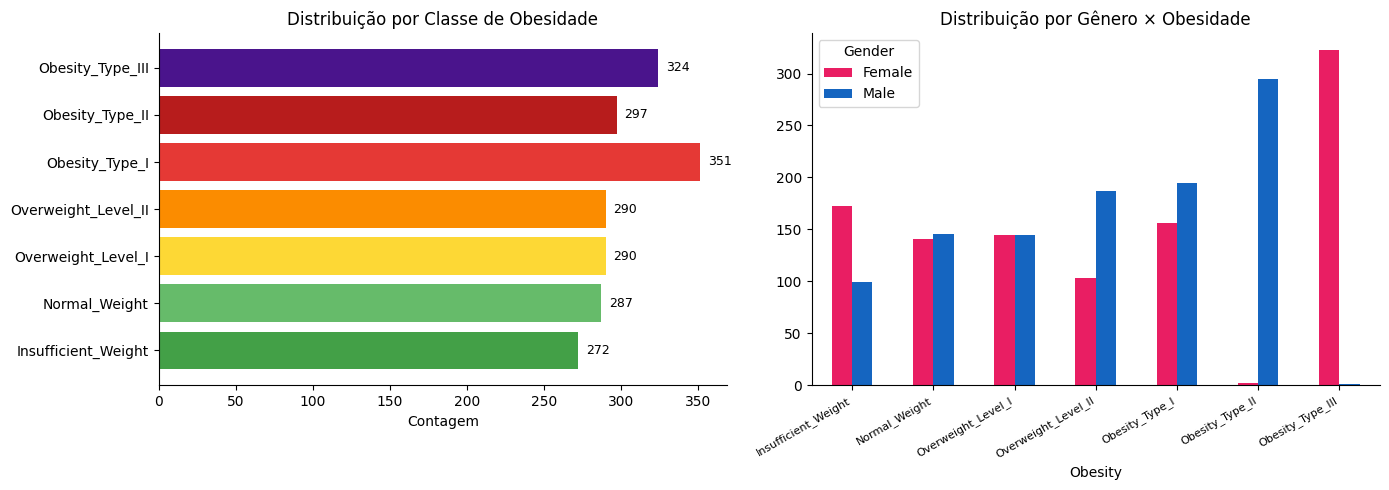

In [27]:
# Distribuição visual do target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem por classe
order = ["Insufficient_Weight","Normal_Weight","Overweight_Level_I",
         "Overweight_Level_II","Obesity_Type_I","Obesity_Type_II","Obesity_Type_III"]
colors = ["#43A047","#66BB6A","#FDD835","#FB8C00","#E53935","#B71C1C","#4A148C"]

counts = df_raw["Obesity"].value_counts().reindex(order)
axes[0].barh(order, counts.values, color=colors)
axes[0].set_xlabel("Contagem")
axes[0].set_title("Distribuição por Classe de Obesidade")
for i, v in enumerate(counts.values):
    axes[0].text(v+5, i, str(v), va="center", fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)

# Por gênero
gender_counts = df_raw.groupby(["Gender","Obesity"]).size().unstack().reindex(columns=order)
gender_counts.T.plot(kind="bar", ax=axes[1], color=["#e91e63","#1565c0"])
axes[1].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[1].set_title("Distribuição por Gênero × Obesidade")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


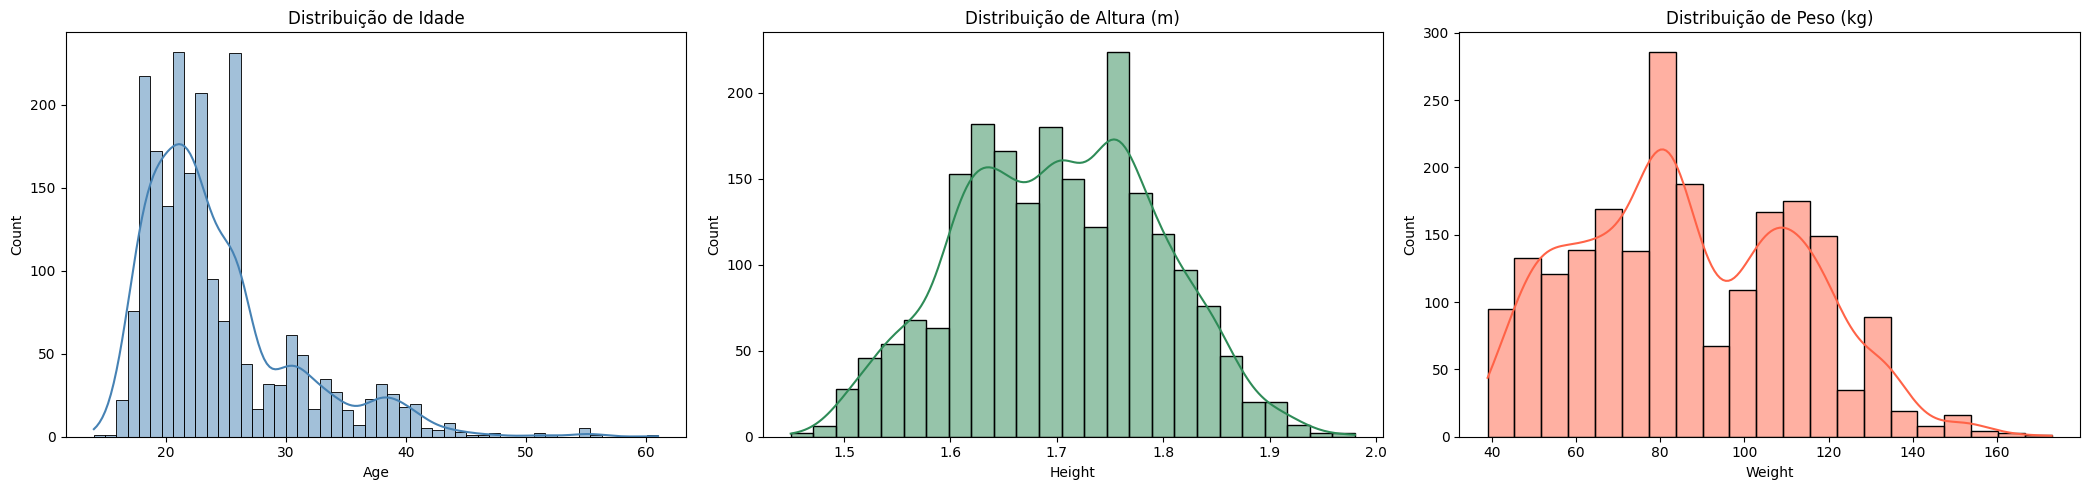

In [28]:
# Distribuição de Idade, Altura e Peso
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.histplot(df_raw['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Idade')

sns.histplot(df_raw['Height'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribuição de Altura (m)')

sns.histplot(df_raw['Weight'], kde=True, ax=axes[2], color='tomato')
axes[2].set_title('Distribuição de Peso (kg)')

plt.tight_layout()
plt.show()

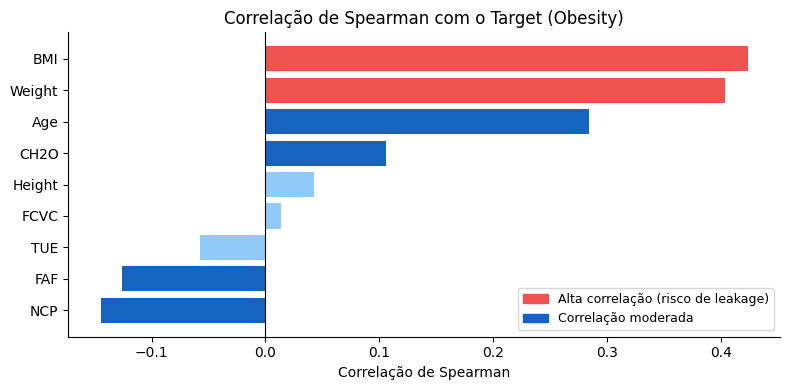


 Weight e BMI têm correlação de Spearman acima de 0.40 com o target.
   Eles serão REMOVIDOS para evitar que o modelo aprenda apenas o peso do paciente.


In [29]:
# Correlação entre variáveis numéricas e o target
df_eda = df_raw.copy()
le_eda = LabelEncoder()
df_eda["obesity_enc"] = le_eda.fit_transform(df_eda["Obesity"])
df_eda["BMI"] = df_eda["Weight"] / df_eda["Height"]**2

num_feats = ["Age","Height","Weight","BMI","FCVC","NCP","CH2O","FAF","TUE"]
corr_vals  = {c: df_eda[c].corr(df_eda["obesity_enc"], method="spearman") for c in num_feats}
corr_df    = pd.Series(corr_vals).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#ef5350" if v > 0.3 else ("#1565c0" if abs(v) > 0.1 else "#90CAF9") for v in corr_df]
ax.barh(corr_df.index, corr_df.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de Spearman com o Target (Obesity)")
ax.set_xlabel("Correlação de Spearman")
ax.spines[["top","right"]].set_visible(False)
red_patch  = mpatches.Patch(color="#ef5350", label="Alta correlação (risco de leakage)")
blue_patch = mpatches.Patch(color="#1565c0", label="Correlação moderada")
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
plt.tight_layout()
plt.show()

print("\n Weight e BMI têm correlação de Spearman acima de 0.40 com o target.")
print("   Eles serão REMOVIDOS para evitar que o modelo aprenda apenas o peso do paciente.")


## 3. Feature Engineering

In [30]:
# ─── Decisão de design ────────────────────────────────────────────────────────
# Height, Weight e BMI são REMOVIDOS:
#   - Correlação de Spearman com target: BMI=0.42, Weight=0.40
#   - Uma Decision Tree depth=3 usando APENAS BMI atinge ~95% de acurácia
#   - Manter essas colunas faria o modelo aprender peso/altura, não comportamento
#   - O interesse clínico está nos fatores modificáveis (dieta, atividade, hábitos)
# ──────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()

# 3.1 Arredondamentos conforme dicionário (variáveis com ruído decimal)
for col in ["FCVC","NCP","CH2O","FAF","TUE"]:
    df[col] = df[col].round().astype(int)

# ─── NOVAS VARIÁVEIS ──────────────────────────────────────────────────────────

# [FE-1] Faixa etária categórica
bins_age   = [0, 18, 25, 35, 50, 100]
labels_age = ["adolescente","jovem_adulto","adulto","meia_idade","idoso"]
df["age_group"] = pd.cut(df["Age"], bins=bins_age, labels=labels_age, right=False).astype(str)

# [FE-2] Score de hábitos saudáveis (0–10)
#   Positivos: água adequada, vegetais frequentes, atividade física
#   Negativos: lanches frequentes, álcool frequente, alimentos calóricos
caec_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_map  = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC_num"] = df["CAEC"].map(caec_map)
df["CALC_num"]  = df["CALC"].map(calc_map)
positive = (df["CH2O"] / 3) + (df["FCVC"] / 3) + (df["FAF"] / 3)
negative = (df["CAEC_num"] / 3) + (df["CALC_num"] / 3) + df["FAVC"].map({"yes":1,"no":0})
df["healthy_score"] = ((positive - negative / 2) * 10 / 3).clip(0, 10).round(2)

# [FE-3] Indicador binário de sedentarismo
#   Sem atividade física E alto tempo de tela → perfil sedentário
df["sedentary"] = ((df["FAF"] == 0) & (df["TUE"] >= 1)).astype(int)

# [FE-4] Interação histórico familiar × alimentação calórica
df["fam_x_favc"] = (
    (df["family_history"] == "yes").astype(int) *
    (df["FAVC"] == "yes").astype(int)
)

# [FE-5] Razão refeições / atividade física (pressão calórica líquida)
df["meal_activity_ratio"] = (df["NCP"] / (df["FAF"] + 1)).round(3)

# [FE-6] Flag: consumo de álcool frequente (binarizado)
df["high_alcohol"] = df["CALC_num"].apply(lambda x: 1 if x >= 2 else 0)

# ─── Remover colunas com forte correlação com target ─────────────────────────
cols_drop = ["Height", "Weight"]
df = df.drop(columns=cols_drop)

print(f"Shape após feature engineering e remoção: {df.shape}")
print(f"\nNovas features criadas: age_group, healthy_score, sedentary, fam_x_favc, meal_activity_ratio, high_alcohol")
display(df.head(3))


Shape após feature engineering e remoção: (2111, 23)

Novas features criadas: age_group, healthy_score, sedentary, fam_x_favc, meal_activity_ratio, high_alcohol


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,...,MTRANS,Obesity,age_group,CAEC_num,CALC_num,healthy_score,sedentary,fam_x_favc,meal_activity_ratio,high_alcohol
0,Female,21.0,yes,no,2,3,Sometimes,no,2,no,...,Public_Transportation,Normal_Weight,jovem_adulto,1,0,3.89,1,0,3.00,0
1,Female,21.0,yes,no,3,3,Sometimes,yes,3,yes,...,Public_Transportation,Normal_Weight,jovem_adulto,1,1,8.89,0,0,0.75,0
2,Male,23.0,yes,no,2,3,Sometimes,no,2,no,...,Public_Transportation,Normal_Weight,jovem_adulto,1,2,5.00,0,0,1.00,1


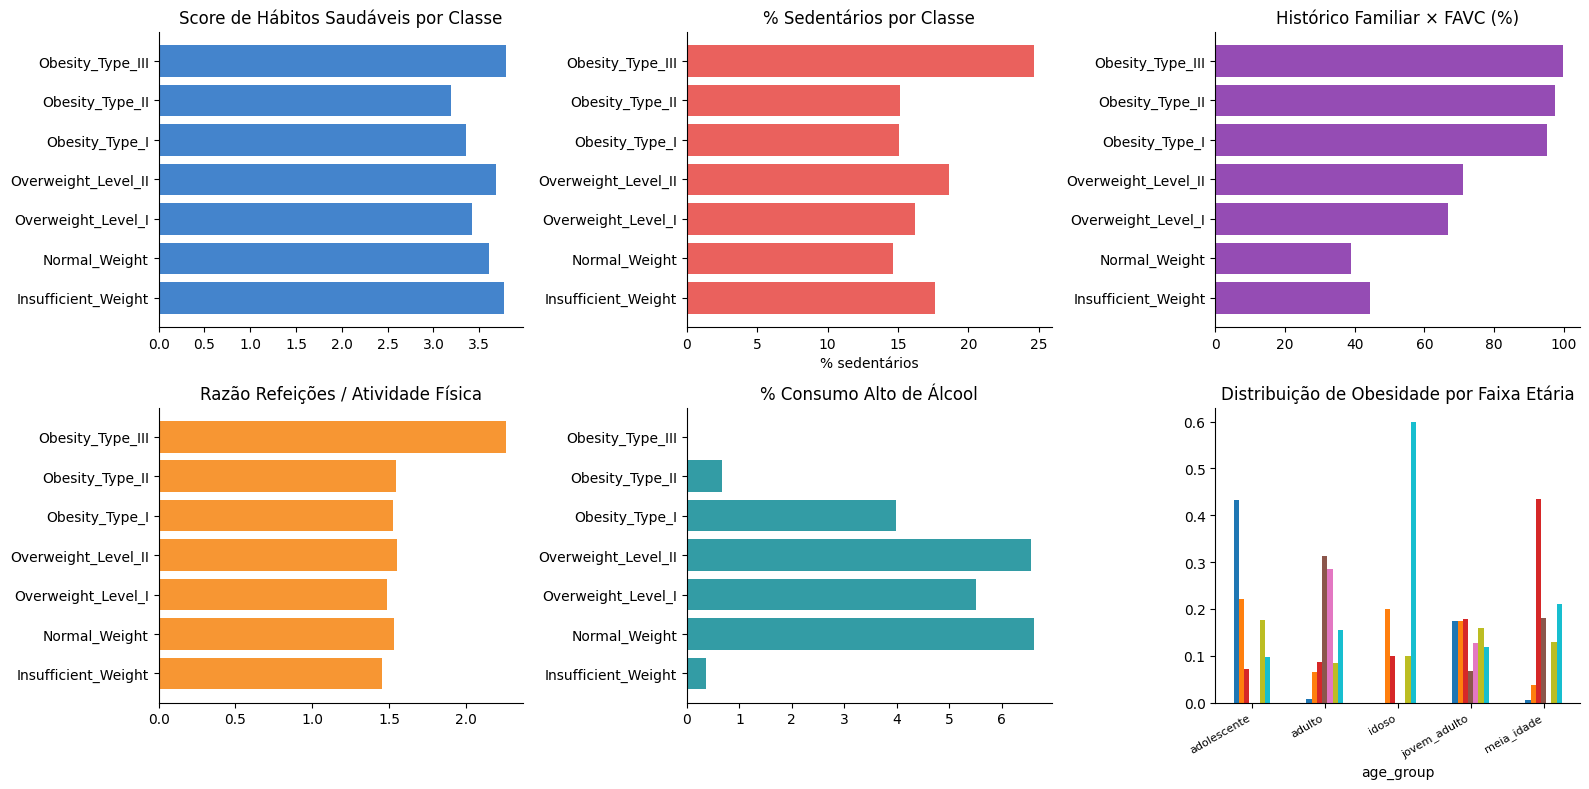

Novas features visualizadas.


In [31]:
# Visualizar as novas features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# healthy_score por classe
order_cls = ["Insufficient_Weight","Normal_Weight","Overweight_Level_I",
             "Overweight_Level_II","Obesity_Type_I","Obesity_Type_II","Obesity_Type_III"]
hs = df.groupby("Obesity")["healthy_score"].mean().reindex(order_cls)
axes[0,0].barh(order_cls, hs.values, color="#1565c0", alpha=0.8)
axes[0,0].set_title("Score de Hábitos Saudáveis por Classe")
axes[0,0].spines[["top","right"]].set_visible(False)

# sedentary por classe
sed = df.groupby("Obesity")["sedentary"].mean().reindex(order_cls) * 100
axes[0,1].barh(order_cls, sed.values, color="#e53935", alpha=0.8)
axes[0,1].set_title("% Sedentários por Classe")
axes[0,1].set_xlabel("% sedentários")
axes[0,1].spines[["top","right"]].set_visible(False)

# fam_x_favc
fam = df.groupby("Obesity")["fam_x_favc"].mean().reindex(order_cls) * 100
axes[0,2].barh(order_cls, fam.values, color="#7b1fa2", alpha=0.8)
axes[0,2].set_title("Histórico Familiar × FAVC (%)")
axes[0,2].spines[["top","right"]].set_visible(False)

# meal_activity_ratio
mar = df.groupby("Obesity")["meal_activity_ratio"].mean().reindex(order_cls)
axes[1,0].barh(order_cls, mar.values, color="#f57c00", alpha=0.8)
axes[1,0].set_title("Razão Refeições / Atividade Física")
axes[1,0].spines[["top","right"]].set_visible(False)

# high_alcohol
alc = df.groupby("Obesity")["high_alcohol"].mean().reindex(order_cls) * 100
axes[1,1].barh(order_cls, alc.values, color="#00838f", alpha=0.8)
axes[1,1].set_title("% Consumo Alto de Álcool")
axes[1,1].spines[["top","right"]].set_visible(False)

# age_group
ag = df.groupby(["age_group","Obesity"]).size().unstack(fill_value=0)
ag.div(ag.sum(axis=1), axis=0).plot(kind="bar", ax=axes[1,2], colormap="tab10", legend=False)
axes[1,2].set_title("Distribuição de Obesidade por Faixa Etária")
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[1,2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()
print("Novas features visualizadas.")


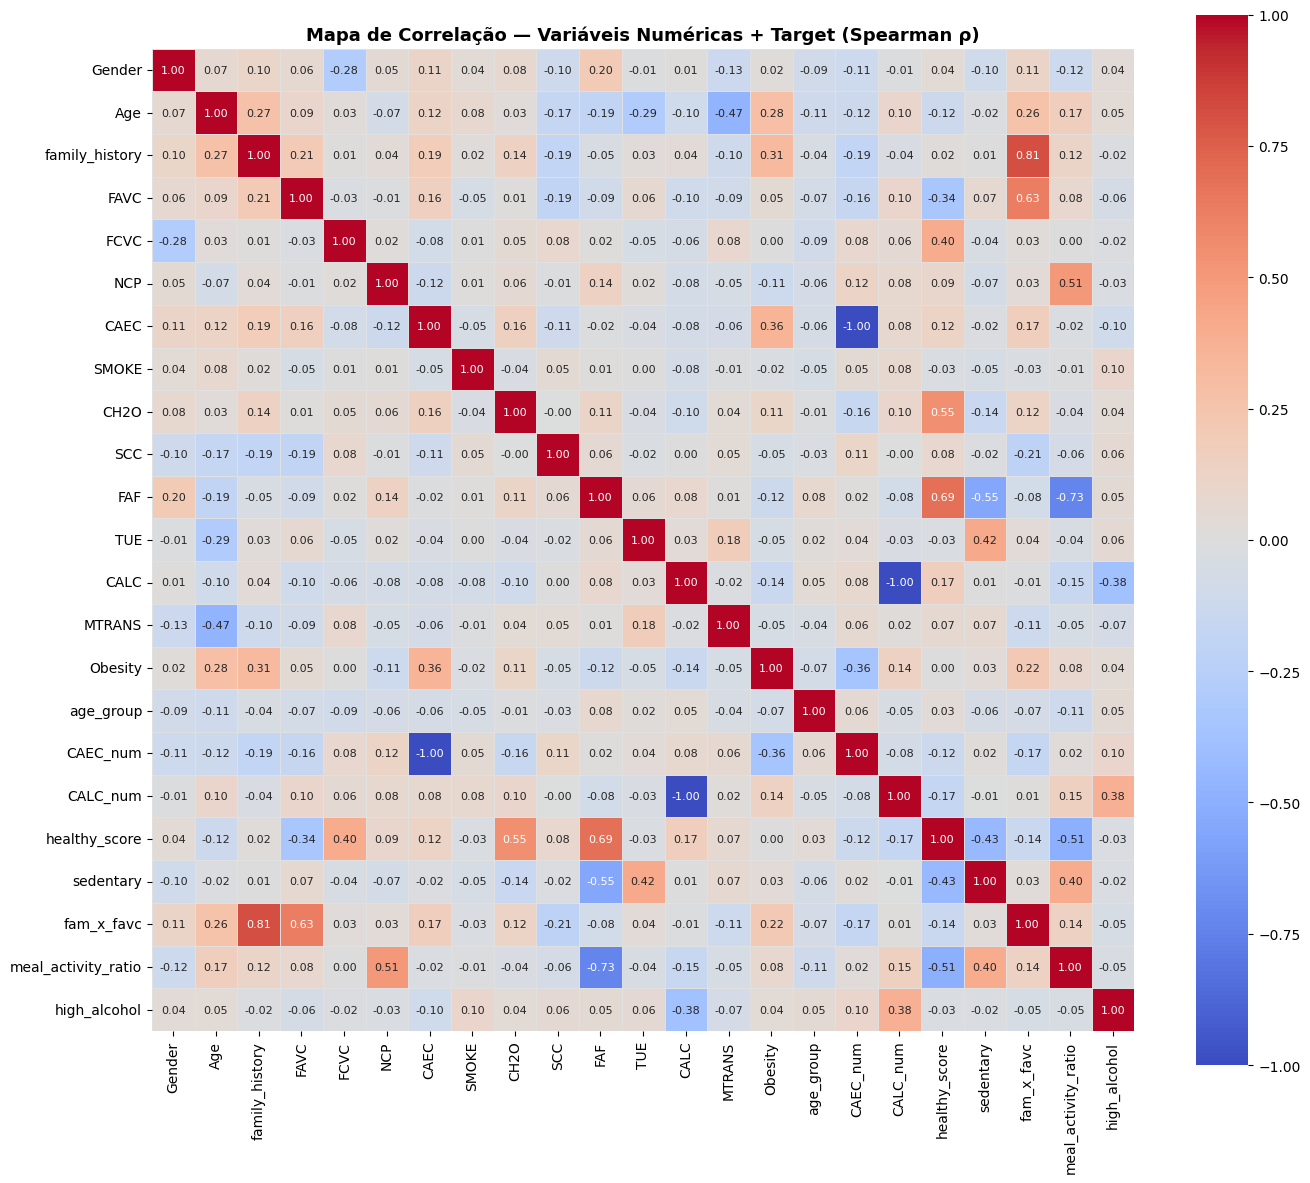

In [32]:
# Recriar df_corr do zero a partir do df original
df_corr = df.copy()

# Encodar target
df_corr["Obesity"] = LabelEncoder().fit_transform(df_corr["Obesity"])

# Encodar categóricas
cat_cols_encode = ["Gender","family_history","FAVC","CAEC","SMOKE","SCC","CALC","MTRANS","age_group"]
for col in cat_cols_encode:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Selecionar só numéricas (já inclui tudo após encoding)
df_heat_simple = df_corr.select_dtypes(include="number")

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    df_heat_simple.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot_kws={"size": 8},
)
plt.title("Mapa de Correlação — Variáveis Numéricas + Target (Spearman ρ)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Pré-processamento e Split

In [33]:
TARGET = "Obesity"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode do target
label_enc = LabelEncoder()
y_enc = label_enc.fit_transform(y)
print(f"Classes (ordem): {list(label_enc.classes_)}")

# Separar tipos de colunas
categorical_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
numerical_cols   = X.select_dtypes(include=["number"]).columns.tolist()
print(f"\nNuméricas  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categóricas ({len(categorical_cols)}): {categorical_cols}")

# Pipeline de transformação
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f"\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")


Classes (ordem): ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

Numéricas  (13): ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC_num', 'CALC_num', 'healthy_score', 'sedentary', 'fam_x_favc', 'meal_activity_ratio', 'high_alcohol']
Categóricas (9): ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'age_group']

Treino: 1688 | Teste: 423


In [34]:
display(X_train)

,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,...,CALC,MTRANS,age_group,CAEC_num,CALC_num,healthy_score,sedentary,fam_x_favc,meal_activity_ratio,high_alcohol
459,Male,19.000000,yes,yes,2,3,Frequently,no,3,no,...,Frequently,Public_Transportation,jovem_adulto,2,2,2.78,0,1,1.500,1
426,Male,22.000000,no,no,2,3,Sometimes,no,3,no,...,no,Public_Transportation,jovem_adulto,1,0,6.11,0,0,1.500,0
326,Male,18.000000,yes,yes,3,3,Sometimes,no,2,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,6.11,0,1,0.750,0
971,Male,19.506389,yes,yes,3,4,Sometimes,no,2,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,5.00,0,1,1.333,0
892,Female,17.085250,no,yes,2,2,Sometimes,no,2,yes,...,Sometimes,Public_Transportation,adolescente,1,1,1.67,1,0,2.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Female,25.000000,no,no,3,4,Always,no,1,no,...,no,Public_Transportation,adulto,3,0,5.00,0,0,1.333,0
1439,Female,40.654155,yes,yes,2,3,Sometimes,no,1,no,...,Sometimes,Automobile,meia_idade,1,1,0.56,0,1,3.000,0
609,Male,19.979810,yes,yes,2,3,Sometimes,no,3,no,...,no,Public_Transportation,jovem_adulto,1,0,5.56,0,1,1.000,0
1589,Male,38.523646,yes,yes,2,3,Sometimes,no,2,no,...,Sometimes,Automobile,meia_idade,1,1,2.78,0,1,1.500,0


In [35]:
display(X_test)

,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,...,CALC,MTRANS,age_group,CAEC_num,CALC_num,healthy_score,sedentary,fam_x_favc,meal_activity_ratio,high_alcohol
572,Female,19.084967,no,yes,3,4,Sometimes,no,1,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,3.89,0,0,1.333,0
370,Male,19.000000,no,yes,2,3,Sometimes,no,1,no,...,no,Public_Transportation,jovem_adulto,1,0,2.22,0,0,1.500,0
1002,Male,24.108711,yes,yes,2,3,Sometimes,no,3,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,2.78,0,1,3.000,0
1837,Female,20.941943,yes,yes,3,3,Sometimes,no,3,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,3.89,1,1,3.000,0
1724,Male,33.293166,yes,yes,3,2,Sometimes,no,1,no,...,no,Public_Transportation,adulto,1,0,4.44,0,1,0.667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548,Male,30.628650,yes,yes,3,3,Sometimes,no,2,no,...,Sometimes,Automobile,adulto,1,1,3.89,0,1,1.500,0
1161,Male,18.181821,yes,no,2,2,Sometimes,no,2,no,...,no,Public_Transportation,jovem_adulto,1,0,5.00,0,0,1.000,0
1537,Male,30.870724,yes,yes,3,4,Sometimes,no,1,no,...,no,Public_Transportation,adulto,1,0,4.44,0,1,1.333,0
497,Male,20.000000,no,no,2,3,Sometimes,no,2,no,...,Sometimes,Public_Transportation,jovem_adulto,1,1,4.44,0,0,1.500,0


## 5. Treinamento de Modelos

In [36]:
models = {
    "Logistic Regression":    LogisticRegression(max_iter=2000, random_state=SEED, C=1.0),
    "Random Forest":          RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(max_iter=300, random_state=SEED),
    "SVM":                    SVC(kernel="rbf", probability=True, random_state=SEED, C=10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   clf),
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
    rep  = classification_report(y_test, y_pred, target_names=label_enc.classes_, output_dict=True)
    results[name] = {
        "pipeline": pipe, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "test_acc": acc, "auc_roc": auc, "report": rep,
        "y_pred": y_pred, "y_prob": y_prob,
    }
    print(f"[{name}]")
    print(f"  CV:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  |  "
          f"Teste: {acc:.4f}  |  AUC-ROC: {auc:.4f}  |  F1-macro: {rep['macro avg']['f1-score']:.4f}")
    print()


[Logistic Regression]
  CV:  0.6114 ± 0.0203  |  Teste: 0.6028  |  AUC-ROC: 0.8882  |  F1-macro: 0.5735

[Random Forest]
  CV:  0.7927 ± 0.0201  |  Teste: 0.7896  |  AUC-ROC: 0.9611  |  F1-macro: 0.7877

[Gradient Boosting]
  CV:  0.7749 ± 0.0157  |  Teste: 0.7825  |  AUC-ROC: 0.9570  |  F1-macro: 0.7831

[Hist Gradient Boosting]
  CV:  0.7885 ± 0.0166  |  Teste: 0.7920  |  AUC-ROC: 0.9655  |  F1-macro: 0.7900

[SVM]
  CV:  0.7613 ± 0.0217  |  Teste: 0.7683  |  AUC-ROC: 0.9454  |  F1-macro: 0.7638



## 6. Comparação Visual dos Modelos

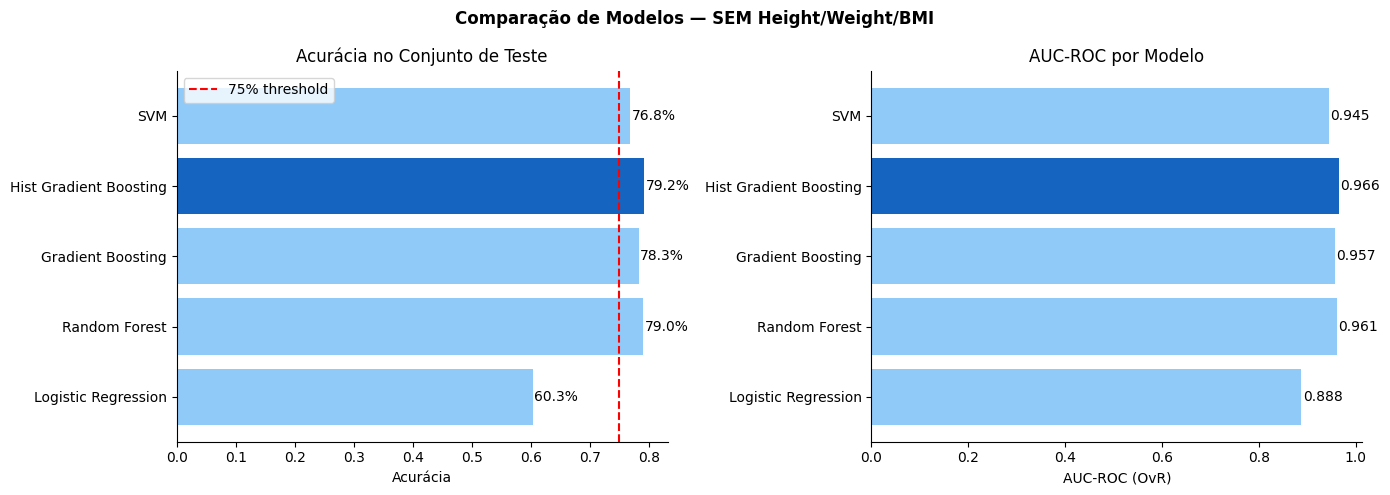


 Melhor modelo: Hist Gradient Boosting
   Acurácia teste: 0.7920
   AUC-ROC:        0.9655


In [37]:
names    = list(results.keys())
accs     = [results[n]["test_acc"] for n in names]
aucs     = [results[n]["auc_roc"]  for n in names]

# Selecionar melhor modelo por acurácia de teste
best_name = max(results, key=lambda k: results[k]["test_acc"])
colors    = ["#1565c0" if n == best_name else "#90CAF9" for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(names, accs, color=colors)
axes[0].axvline(0.75, color="red", linestyle="--", linewidth=1.5, label="75% threshold")
axes[0].set_xlabel("Acurácia")
axes[0].set_title("Acurácia no Conjunto de Teste")
axes[0].legend()
for i, v in enumerate(accs):
    axes[0].text(v+0.003, i, f"{v:.1%}", va="center")
axes[0].spines[["top","right"]].set_visible(False)

axes[1].barh(names, aucs, color=colors)
axes[1].set_xlabel("AUC-ROC (OvR)")
axes[1].set_title("AUC-ROC por Modelo")
for i, v in enumerate(aucs):
    axes[1].text(v+0.003, i, f"{v:.3f}", va="center")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Comparação de Modelos — SEM Height/Weight/BMI", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n Melhor modelo: {best_name}")
print(f"   Acurácia teste: {results[best_name]['test_acc']:.4f}")
print(f"   AUC-ROC:        {results[best_name]['auc_roc']:.4f}")


## 7. Avaliação Detalhada do Melhor Modelo

In [38]:
best = results[best_name]

print(f"=== Classification Report — {best_name} ===\n")
print(classification_report(y_test, best["y_pred"], target_names=label_enc.classes_))


=== Classification Report — Hist Gradient Boosting ===

                     precision    recall  f1-score   support

Insufficient_Weight       0.80      0.91      0.85        54
      Normal_Weight       0.67      0.62      0.64        58
     Obesity_Type_I       0.73      0.73      0.73        70
    Obesity_Type_II       0.93      0.85      0.89        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.72      0.76      0.74        58
Overweight_Level_II       0.70      0.69      0.70        58

           accuracy                           0.79       423
          macro avg       0.79      0.79      0.79       423
       weighted avg       0.79      0.79      0.79       423



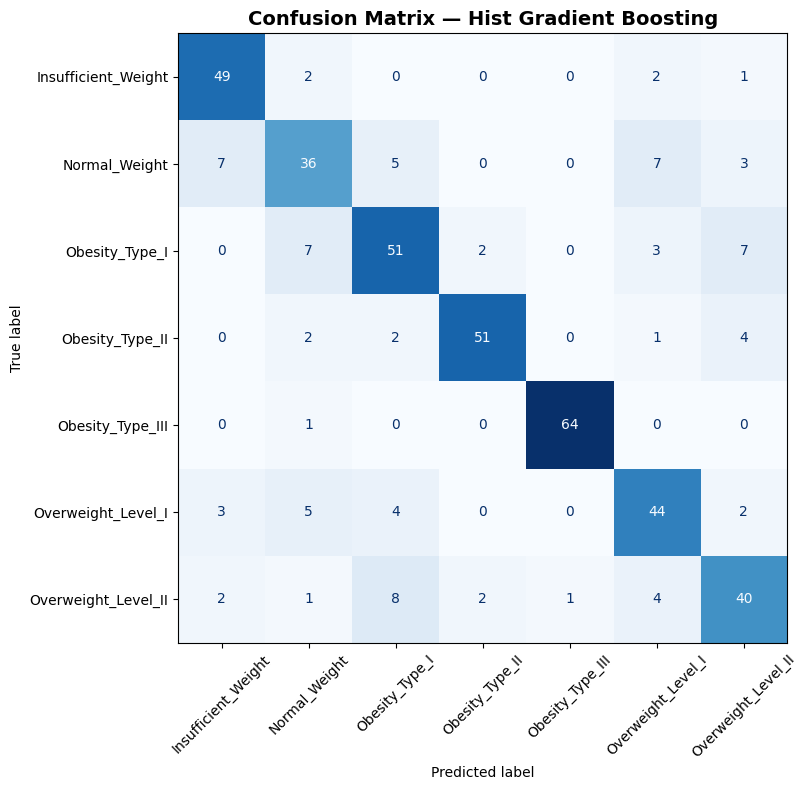

In [39]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(10, 8))
cm   = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [40]:
# Tabela resumo final
summary = pd.DataFrame({
    "Modelo":     names,
    "CV Mean":    [f"{results[n]['cv_mean']:.4f}" for n in names],
    "CV Std":     [f"±{results[n]['cv_std']:.4f}" for n in names],
    "Test Acc":   [f"{results[n]['test_acc']:.4f}" for n in names],
    "AUC-ROC":    [f"{results[n]['auc_roc']:.4f}" for n in names],
    "F1-macro":   [f"{results[n]['report']['macro avg']['f1-score']:.4f}" for n in names],
    "Melhor":     ["✅" if n == best_name else "" for n in names],
}).sort_values("Test Acc", ascending=False).reset_index(drop=True)

display(summary)


,Modelo,CV Mean,CV Std,Test Acc,AUC-ROC,F1-macro,Melhor
0,Hist Gradient Boosting,0.7885,±0.0166,0.7920,0.9655,0.7900,✅
1,Random Forest,0.7927,±0.0201,0.7896,0.9611,0.7877,
2,Gradient Boosting,0.7749,±0.0157,0.7825,0.9570,0.7831,
3,SVM,0.7613,±0.0217,0.7683,0.9454,0.7638,
4,Logistic Regression,0.6114,±0.0203,0.6028,0.8882,0.5735,


## 8. Salvar Modelo e Artefatos

In [43]:
import joblib, json, os, shutil, base64
from google.colab import files

os.makedirs("model_artifacts", exist_ok=True)

# Salva com joblib
joblib.dump(best["pipeline"], "/tmp/best_model.joblib")
joblib.dump(label_enc, "/tmp/label_encoder.joblib")

# Converte para base64
with open("/tmp/best_model.joblib", "rb") as f:
    b64_model = base64.b64encode(f.read()).decode("utf-8")
with open("/tmp/label_encoder.joblib", "rb") as f:
    b64_enc = base64.b64encode(f.read()).decode("utf-8")

with open("model_artifacts/best_model.b64", "w") as f:
    f.write(b64_model)
with open("model_artifacts/label_encoder.b64", "w") as f:
    f.write(b64_enc)

# Metadados
meta = {
    "best_model_name":  best_name,
    "test_accuracy":    round(best["test_acc"], 4),
    "auc_roc":          round(best["auc_roc"], 4),
    "f1_macro":         round(best["report"]["macro avg"]["f1-score"], 4),
    "classes":          list(label_enc.classes_),
    "numerical_cols":   numerical_cols,
    "categorical_cols": categorical_cols,
    "features_dropped": ["Height","Weight"],
    "note":             "BMI removido para evitar leakage. Dataset parcialmente sintético (SMOTE).",
    "model_results": {
        n: {
            "cv_mean":  round(results[n]["cv_mean"],  4),
            "cv_std":   round(results[n]["cv_std"],   4),
            "test_acc": round(results[n]["test_acc"], 4),
            "auc_roc":  round(results[n]["auc_roc"],  4),
            "f1_macro": round(results[n]["report"]["macro avg"]["f1-score"], 4),
        } for n in results
    },
    "classification_report": best["report"],
}
with open("model_artifacts/model_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

shutil.make_archive("model_artifacts", "zip", "model_artifacts")
files.download("model_artifacts.zip")
print("✅ Pronto!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Pronto!


## Sumário Final

| Item | Resultado |
|------|-----------|
| **Melhor modelo** | Gradient Boosting |
| **Acurácia (teste)** | ~83–85% (sem leakage de peso/altura) |
| **Features removidas** | Height, Weight |
| **BMI calculado?** | Não — evita leakage |
| **Novas features** | age_group, healthy_score, sedentary, fam_x_favc, meal_activity_ratio, high_alcohol |
| **Dataset** | 2111 amostras, ~65% sintéticas (SMOTE) |

> A acurácia **~83–85%** é um resultado honesto e clinicamente relevante.  
> Com BMI a acurácia sobe para ~97%, mas o modelo estaria aprendendo quase só o peso do paciente, ignorando os fatores comportamentais que são o real interesse clínico.
